# Parse `FIT` file and cue-sheet `CSV` from [ridewithgps.com](ridewithgps.com)

{'distance_until_instruction': np.float64(65.34322832493659),
 'prev_instruction': (558.824470, -2067) => Continue onto Woodstock Road,
 'instruction': (603.350532, -2164) => Continue onto St Giles',
 'next_instruction': (741.388789, -2644) => Keep left onto St Giles',
 'travel_bearing': 123.4070°,
 'route_bearing': 155.3679°,
 'total_distance_covered_along_route': np.float64(1414.6567716750635)}

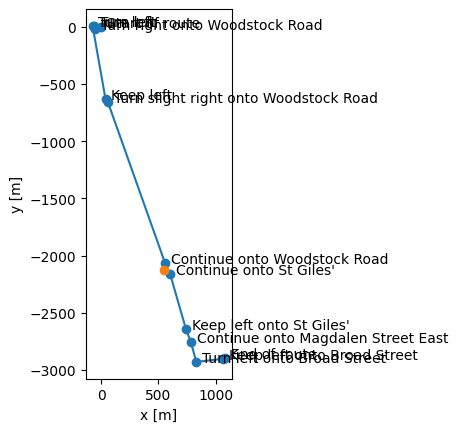

In [4]:
import pandas as pd
from fit import fit_to_route
from matplotlib import pyplot as plt
from route import Angle, Coord

route = fit_to_route("stav_to_trin.fit")
cues = pd.read_csv("stav_to_trin_cuesheet.csv")
route.set_instructions_text(cues["Notes"])
route.set_instructions_icons(cues["Type"])
route.set_elevations(cues["Elevation (m)"])
route.plot()

me = Coord(Angle(deg=51.75866), Angle(deg=-1.261))
plt.plot(*(me.project() - route.start.project()), "o")
route.instruct(me)